# **Phân tích quy luật lạm dụng hành vi Protocol**
**Mục tiêu:** 
- Tìm quy luật hành vi lạm dụng protocol như:
```
IF:
  protocol_type_TCP
  AND failed_logins_high
  AND session_duration_low

THEN:
  attack_detected
```

- Phát hiện:
    - Mức độ sử dụng của Protocol đáng ngờ
    - Mức độ lạm dụng protocol + login 
    - Mức độ bất thường của protocol + browser 
    - Mức độ lạm dụng protocol + reputation 


## **1. Chuẩn bị vấn đề**

### 1.1. Import các thư viện cần thiết

In [55]:
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer

from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)

### 1.2. Tải dữ liệu

In [56]:
df = pd.read_parquet(
    "../data_processed/cleaned_data.parquet"
)

df.columns = [
    c.strip().lower()
    for c in df.columns
]


### 1.3. Chọn các features

In [ ]:
features = [
    "protocol_type",
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins",
    "browser_type",
    "encryption_used",
    "unusual_time_access",
    "attack_detected"
]

df = df[features].copy()
df = df.fillna(0)

### 1.4. Rời rạc hóa các biến số

In [ ]:
numeric_cols = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins"
]

disc = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)

X_disc = disc.fit_transform(
    df[numeric_cols]
)

X_disc = pd.DataFrame(
    X_disc,
    columns=numeric_cols
)


## **3. Thực hiện vấn đề**

### 3.1. Xây dựng transactions

In [59]:
transactions = {}

# NUMERIC FEATURES
for col in X_disc.columns:

    vals = X_disc[col].values

    transactions[f"{col}_low"] = (
        vals == 0
    ).astype(np.uint8)

    transactions[f"{col}_mid"] = (
        vals == 1
    ).astype(np.uint8)

    transactions[f"{col}_high"] = (
        vals == 2
    ).astype(np.uint8)


# PROTOCOL TYPE
protocol_dummies = pd.get_dummies(
    df["protocol_type"],
    prefix="protocol_type",
    dtype=np.uint8
)

for col in protocol_dummies.columns:
    transactions[col] = protocol_dummies[col]

# BROWSER TYPE
browser_dummies = pd.get_dummies(
    df["browser_type"],
    prefix="browser_type",
    dtype=np.uint8
)

for col in browser_dummies.columns:
    transactions[col] = browser_dummies[col]

# ENCRYPTION
enc_dummies = pd.get_dummies(
    df["encryption_used"],
    prefix="encryption_used",
    dtype=np.uint8
)

for col in enc_dummies.columns:
    transactions[col] = enc_dummies[col]

# BOOLEAN FEATURES
transactions["unusual_time_access"] = (
    df["unusual_time_access"]
    .astype(np.uint8)
)

transactions["attack_detected"] = (
    df["attack_detected"]
    .astype(np.uint8)
)

# FINAL TRANSACTION TABLE
transactions = pd.DataFrame(
    transactions,
    dtype=np.uint8
)

print("\nTransaction shape:", transactions.shape)


Transaction shape: (7571, 27)


### 3.2. Khởi tạo fpgrowth và luật kết hợp

In [60]:
freq_items = fpgrowth(
    transactions.astype(bool),
    min_support=0.03,
    use_colnames=True
)

print("Frequent itemsets:", len(freq_items))

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.60
)

print("Generated rules:", len(rules))

Frequent itemsets: 1981
Generated rules: 1301


### 3.3. Xây dựng luật kết hợp

In [ ]:

# KEEP ONLY ATTACK RULES
rules = rules[
    rules["consequents"]
    .astype(str)
    .str.contains("attack_detected")
].copy()

# REMOVE SELF RULES
rules = rules[
    ~rules["antecedents"]
    .astype(str)
    .str.contains("attack_detected")
]

# RULE METRICS
rules["rule_size"] = (
    rules["antecedents"]
    .apply(len)
)

rules["score"] = (
    rules["support"]
    * rules["confidence"]
    * rules["lift"]
)

# SORT RULES
rules = rules.sort_values(
    by=[
        "score",
        "lift",
        "confidence"
    ],
    ascending=False
)

# STRONG PROTOCOL ABUSE RULES
strong_rules = rules[
    (rules["confidence"] > 0.7)
    &
    (rules["lift"] > 1.4)
    &
    (rules["rule_size"] >= 2)
]

### 3.4. Kiểm tra kết quả

In [62]:
cols = [
    "antecedents",
    "support",
    "confidence",
    "lift",
    "score",
    "rule_size"
]

print("TOP PROTOCOL ABUSE RULES: ")

print(
    rules[cols]
    .head(30)
)

TOP PROTOCOL ABUSE RULES: 
                                            antecedents   support  confidence  \
1027  frozenset({failed_logins_high, login_attempts_...  0.117290    0.649123   
234   frozenset({failed_logins_high, ip_reputation_s...  0.102364    0.634726   
1040  frozenset({failed_logins_high, login_attempts_...  0.083609    0.654602   
269   frozenset({login_attempts_high, ip_reputation_...  0.079910    0.640890   
237   frozenset({failed_logins_high, protocol_type_T...  0.074759    0.653580   
1030  frozenset({failed_logins_high, encryption_used...  0.069740    0.633094   
1099  frozenset({failed_logins_high, network_packet_...  0.068551    0.603488   
249   frozenset({failed_logins_high, encryption_used...  0.062475    0.614286   
284   frozenset({login_attempts_high, protocol_type_...  0.055079    0.652582   
1033  frozenset({browser_type_Chrome, failed_logins_...  0.061286    0.617843   
239   frozenset({browser_type_Chrome, failed_logins_...  0.056003    0.640483   
7

### 3.5. Biểu diễn luật qua đồ thị

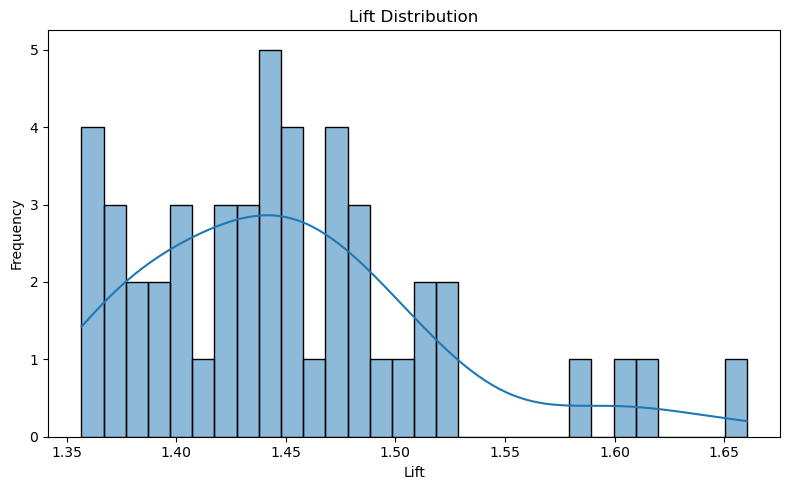

In [63]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rules["lift"],
    bins=30,
    kde=True
)

plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



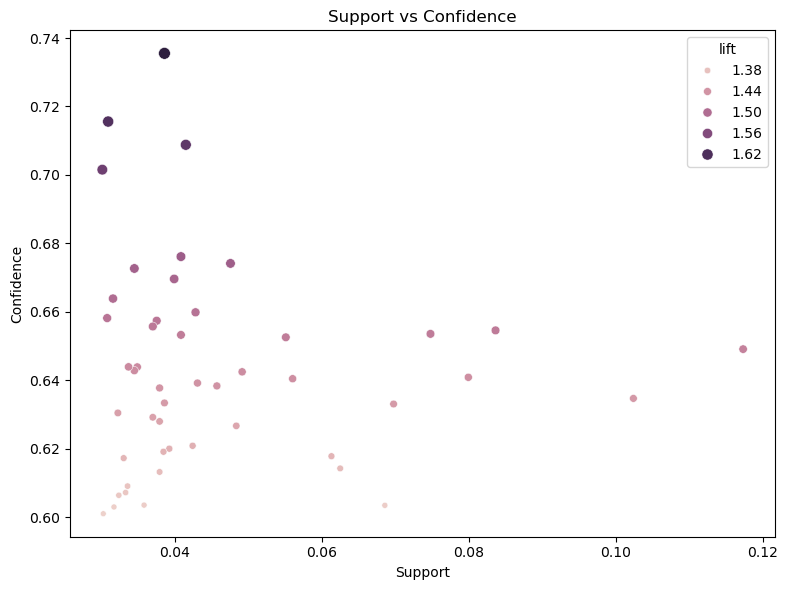

In [64]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    size="lift",
    hue="lift"
)

plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.tight_layout()
plt.show()

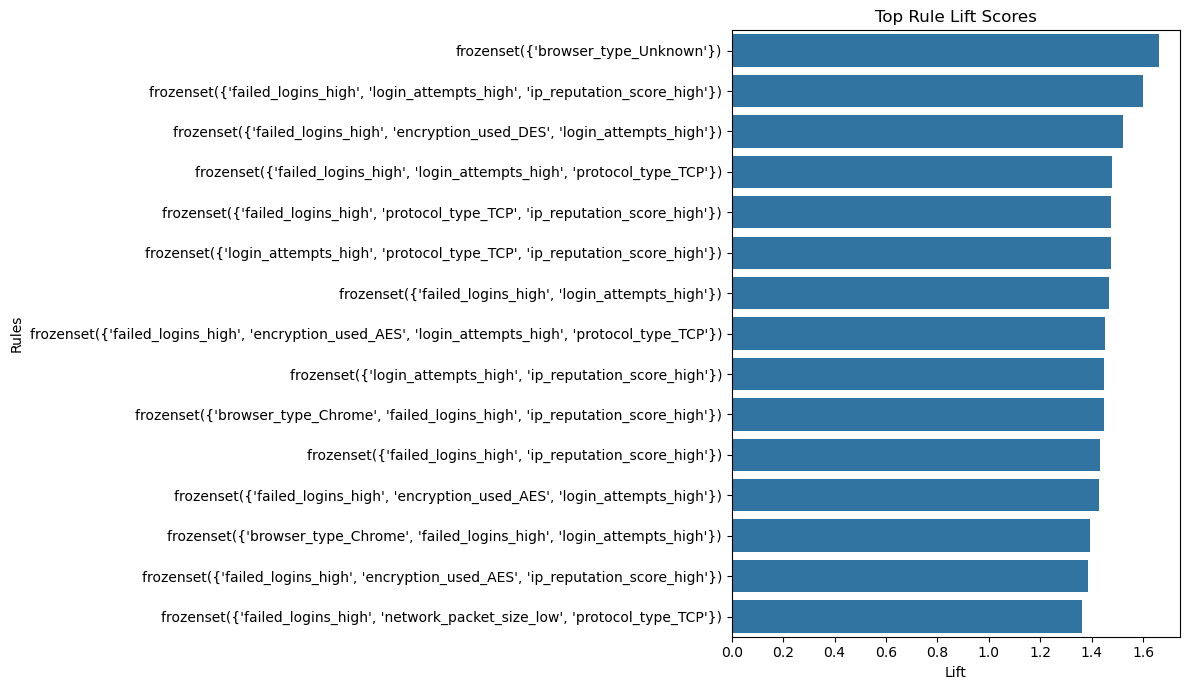

In [72]:
top_rules = rules.head(15).copy().sort_values(by="lift", ascending=False)

top_rules["rule_name"] = top_rules[
    "antecedents"
].astype(str)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_rules,
    x="lift",
    y="rule_name"
)

plt.title("Top Rule Lift Scores")
plt.xlabel("Lift")
plt.ylabel("Rules")

plt.tight_layout()
plt.show()

# **Kết thúc**